In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from zipfile import ZipFile

In [3]:
zip_file = ZipFile("6_ads.zip")

ads_data_df = pd.read_csv(zip_file.open("ads_data.csv"), parse_dates=["date", "time"])
ads_clients_data_df = pd.read_csv(zip_file.open("ads_clients_data.csv"), parse_dates=["date", "create_date"])

In [4]:
sns.set(
    font_scale=2,
    style="whitegrid",
    rc={"figure.figsize":(20,7)}
)

In [5]:
ads_data_df.head()

,date,time,event,platform,ad_id,client_union_id,campaign_union_id,ad_cost_type,ad_cost,has_video,target_audience_count
0,2019-04-01,2019-04-01 00:00:48,view,android,45061,34734,45061,CPM,200.6,0,1955269
1,2019-04-01,2019-04-01 00:00:48,view,web,121288,121288,121288,CPM,187.4,0,232011
2,2019-04-01,2019-04-01 00:01:03,view,android,102737,102535,102564,CPC,60.7,0,4410
3,2019-04-01,2019-04-01 00:01:03,view,android,107564,106914,107564,CPM,217.3,0,62711
4,2019-04-01,2019-04-01 00:01:09,view,android,4922,37,4400,CPC,60.1,0,1183501


In [6]:
ads_clients_data_df.head()

,date,client_union_id,community_id,create_date
0,2020-05-07,1,-130371893,2018-12-24
1,2020-05-07,2,-130304626,2019-02-10
2,2020-05-07,3,-130462599,2019-01-25
3,2020-05-07,4,-130574300,2018-12-09
4,2020-05-07,5,-130292358,2019-01-08


In [7]:
ads_by_view_df = ads_data_df.query("event == 'view'") \
    .groupby("ad_id", as_index=False) \
    .agg({"platform": "count"}) \
    .rename(columns={"platform": "count_"}) \
    .sort_values(by="count_")

In [8]:
ads_by_view_df.head()

,ad_id,count_
659,98274,10
460,42507,11
784,112872,11
755,110591,13
709,106809,13


In [9]:
ads_by_view_df["count_"] = np.log(ads_by_view_df["count_"])

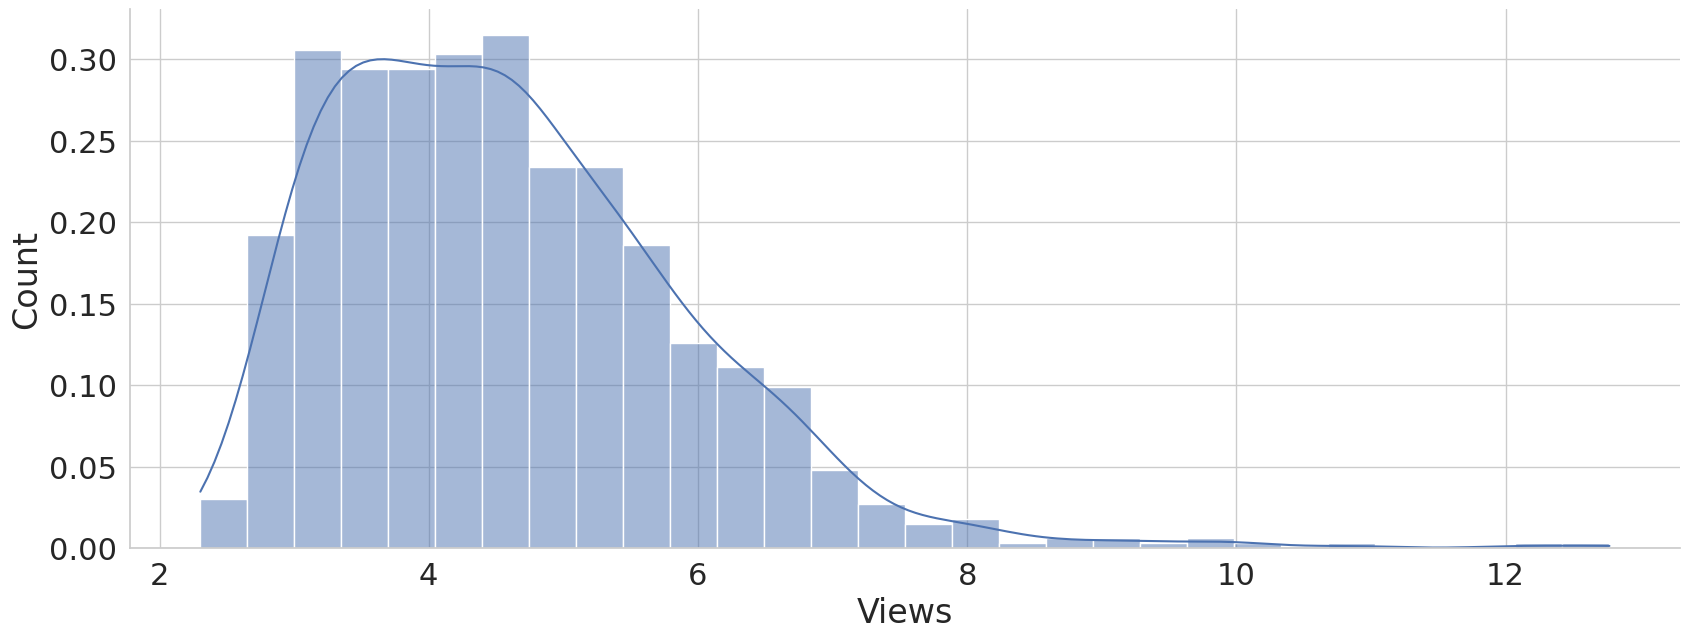

In [10]:
ax = sns.histplot(data=ads_by_view_df, x="count_", kde=True, stat="density")

ax.set_xlabel("Views")
ax.set_ylabel("Count")

sns.despine()

In [11]:
ads_data_by_date_df = ads_data_df[ads_data_df['event'] == 'view'] \
    .groupby(['ad_id', 'date'], as_index=False) \
    .agg({'platform': 'count'}) \
    .rename(columns={'platform': 'count_'})

ads_data_by_date_pivot_table = ads_data_by_date_df.pivot(index='ad_id', columns='date', values='count_')
ads_data_by_date_pivot_table = ads_data_by_date_pivot_table.fillna(0)

In [12]:
avg_by_date = ads_data_by_date_pivot_table.mean()

In [13]:
rolling_ads_by_date = avg_by_date.rolling(window=2).mean().round(2)

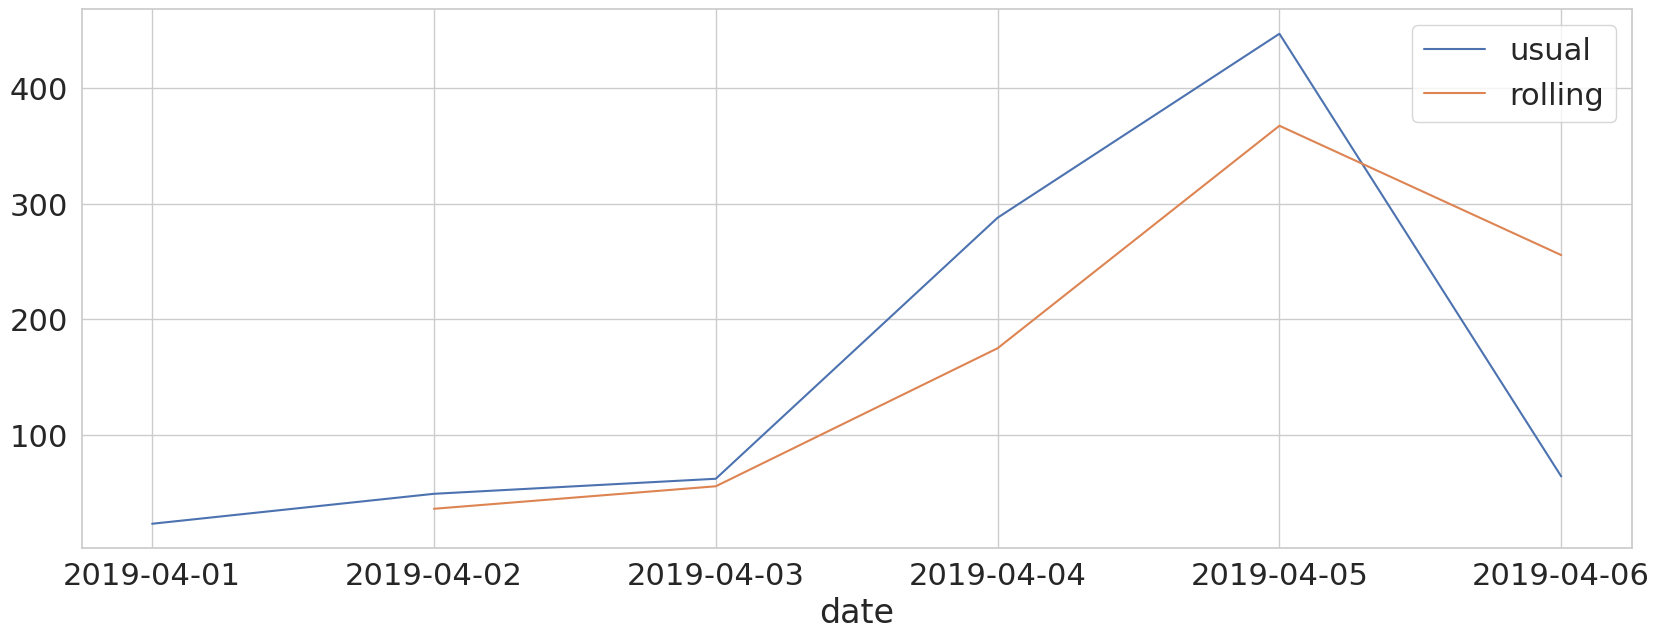

In [14]:
fig, ax = plt.subplots()

sns.lineplot(data=avg_by_date, ax=ax, label='usual')
sns.lineplot(data=rolling_ads_by_date, ax=ax, label='rolling')

plt.legend()
plt.show()

In [15]:
abs(rolling_ads_by_date - avg_by_date).sort_values(ascending=False)

date
2019-04-06    191.636987
2019-04-04    113.003138
2019-04-05     79.656485
2019-04-02     12.965481
2019-04-03      6.509540
2019-04-01           NaN
dtype: float64

In [16]:
ads_clients_df = ads_data_df.merge(right=ads_clients_data_df, on=['client_union_id'], suffixes=('_client_data', '_ad_data'))
ads_clients_df.head(3)

,date_client_data,time,event,platform,ad_id,client_union_id,campaign_union_id,ad_cost_type,ad_cost,has_video,target_audience_count,date_ad_data,community_id,create_date
0,2019-04-01,2019-04-01 00:00:48,view,android,45061,34734,45061,CPM,200.6,0,1955269,2020-05-07,-130129582,2018-12-04
1,2019-04-01,2019-04-01 00:00:48,view,web,121288,121288,121288,CPM,187.4,0,232011,2020-05-07,-130337958,2018-12-25
2,2019-04-01,2019-04-01 00:01:03,view,android,102737,102535,102564,CPC,60.7,0,4410,2020-05-07,-130393498,2018-11-13


In [17]:
ads_clients_df['difference'] = ads_clients_df['date_ad_data'] - ads_clients_df['create_date']

In [18]:
ads_clients_df.head(3)

,date_client_data,time,event,platform,ad_id,client_union_id,campaign_union_id,ad_cost_type,ad_cost,has_video,target_audience_count,date_ad_data,community_id,create_date,difference
0,2019-04-01,2019-04-01 00:00:48,view,android,45061,34734,45061,CPM,200.6,0,1955269,2020-05-07,-130129582,2018-12-04,520 days
1,2019-04-01,2019-04-01 00:00:48,view,web,121288,121288,121288,CPM,187.4,0,232011,2020-05-07,-130337958,2018-12-25,499 days
2,2019-04-01,2019-04-01 00:01:03,view,android,102737,102535,102564,CPC,60.7,0,4410,2020-05-07,-130393498,2018-11-13,541 days


In [19]:
first_ad = ads_clients_df.groupby('client_union_id').difference.min()

In [20]:
first_ad.mean().days

524

In [21]:
threshold = pd.Timedelta(500, unit='day')

In [22]:
lt_500 = first_ad[first_ad < threshold]

In [23]:
np.round(len(lt_500) / ads_clients_data_df.client_union_id.nunique() * 100, 2)

np.float64(0.26)

In [25]:
bins = [400, 500, 600, 700, 800, 900]
bins = [pd.Timedelta(b, 'days') for b in bins]
labels = ['400-500', '500-600', '600-700', '700-800', '800-900']

In [30]:
intervals_ads_count = pd.cut(first_ad, bins=bins, labels=labels)
intervals_ads_count

client_union_id
1         400-500
9         500-600
13        400-500
16        500-600
20        400-500
           ...   
122004    400-500
122013    500-600
122023    500-600
122031    400-500
122078    400-500
Name: difference, Length: 838, dtype: category
Categories (5, str): ['400-500' < '500-600' < '600-700' < '700-800' < '800-900']

In [41]:
interval_count = intervals_ads_count.value_counts(ascending=False)

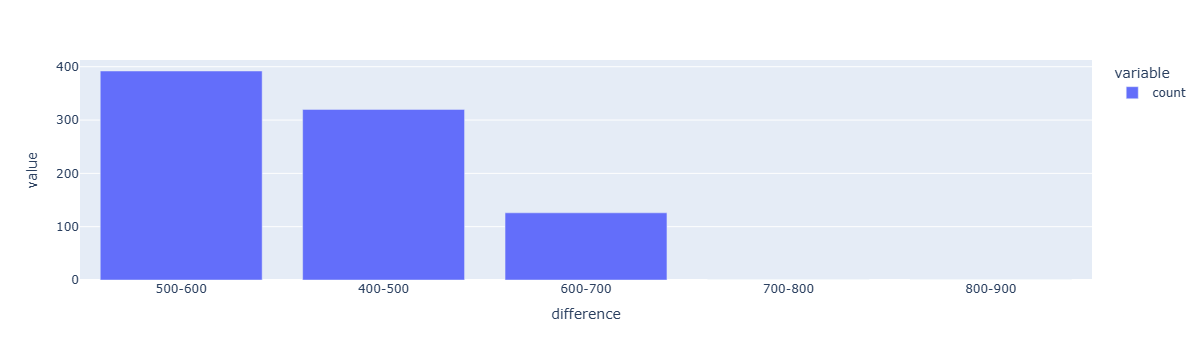

In [42]:
fig = px.bar(interval_count)
fig.show()